In [1]:
import pandas as pd

In [2]:
data = pd.read_excel("NLPMiniVeriSeti.xlsx")

In [3]:
data.head(3)

,ID,METİN,TUR
0,1,Bugün her şey gerçekten çok güzel gitti.,açık
1,2,Bu haberi görünce çok mutlu oldum.,açık
2,3,Sonuçtan hiç memnun kalmadım.,açık


In [4]:
data.shape

(20, 3)

In [5]:
data["TUR"].value_counts()

TUR
internet_dili    6
ironi            5
bağlam           5
açık             4
Name: count, dtype: int64

In [6]:
data.columns

Index(['ID', 'METİN', 'TUR'], dtype='object')

In [7]:
data.isnull().sum()

ID       0
METİN    0
TUR      0
dtype: int64

In [8]:
data["METİN"].duplicated().sum()

np.int64(0)

In [9]:
data["insan_etiketi"] = ""

In [10]:
data.head()

,ID,METİN,TUR,insan_etiketi
0,1,Bugün her şey gerçekten çok güzel gitti.,açık,
1,2,Bu haberi görünce çok mutlu oldum.,açık,
2,3,Sonuçtan hiç memnun kalmadım.,açık,
3,4,Bu uygulama tam bir hayal kırıklığı.,açık,
4,5,Sonunda istediğim sonucu aldım.,ironi,


In [11]:
data[["ID", "METİN", "TUR"]]

,ID,METİN,TUR
0,1,Bugün her şey gerçekten çok güzel gitti.,açık
1,2,Bu haberi görünce çok mutlu oldum.,açık
2,3,Sonuçtan hiç memnun kalmadım.,açık
3,4,Bu uygulama tam bir hayal kırıklığı.,açık
4,5,Sonunda istediğim sonucu aldım.,ironi
5,6,"Harika, yine üç saat bekledik.",ironi
6,7,"Ne kadar düşünceli, mesajıma iki gün sonra cev...",ironi
7,8,"Muhteşem bir hizmet, siparişim hâlâ gelmedi.",ironi
8,9,"Bravo, yine tam zamanında sistemi bozmuşlar.",ironi
9,10,"Çok iyi olmuş, zaten herkesin buna ihtiyacı va...",bağlam


In [12]:
data["tur"] = [
    "açık", "açık", "açık", "açık", "açık",
    "ironi", "ironi", "ironi", "ironi", "ironi",
    "bağlam", "bağlam", "bağlam", "bağlam", "bağlam",
    "internet_dili", "internet_dili", "internet_dili", "internet_dili", "internet_dili"
]

In [13]:
data[["ID", "METİN", "TUR"]]

,ID,METİN,TUR
0,1,Bugün her şey gerçekten çok güzel gitti.,açık
1,2,Bu haberi görünce çok mutlu oldum.,açık
2,3,Sonuçtan hiç memnun kalmadım.,açık
3,4,Bu uygulama tam bir hayal kırıklığı.,açık
4,5,Sonunda istediğim sonucu aldım.,ironi
5,6,"Harika, yine üç saat bekledik.",ironi
6,7,"Ne kadar düşünceli, mesajıma iki gün sonra cev...",ironi
7,8,"Muhteşem bir hizmet, siparişim hâlâ gelmedi.",ironi
8,9,"Bravo, yine tam zamanında sistemi bozmuşlar.",ironi
9,10,"Çok iyi olmuş, zaten herkesin buna ihtiyacı va...",bağlam


In [14]:
data["insan_etiketi"] = [
    "pozitif",
    "pozitif",
    "negatif",
    "negatif",
    "pozitif",
    "negatif",
    "negatif",
    "negatif",
    "negatif",
    "negatif",
    "nötr",
    "nötr",
    "nötr",
    "negatif",
    "nötr",
    "negatif",
    "negatif",
    "negatif",
    "negatif",
    "negatif"
]

In [15]:
data[["ID", "METİN", "insan_etiketi"]]

,ID,METİN,insan_etiketi
0,1,Bugün her şey gerçekten çok güzel gitti.,pozitif
1,2,Bu haberi görünce çok mutlu oldum.,pozitif
2,3,Sonuçtan hiç memnun kalmadım.,negatif
3,4,Bu uygulama tam bir hayal kırıklığı.,negatif
4,5,Sonunda istediğim sonucu aldım.,pozitif
5,6,"Harika, yine üç saat bekledik.",negatif
6,7,"Ne kadar düşünceli, mesajıma iki gün sonra cev...",negatif
7,8,"Muhteşem bir hizmet, siparişim hâlâ gelmedi.",negatif
8,9,"Bravo, yine tam zamanında sistemi bozmuşlar.",negatif
9,10,"Çok iyi olmuş, zaten herkesin buna ihtiyacı va...",negatif


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [22]:
tfidf = TfidfVectorizer()
x = tfidf.fit_transform(data["METİN"])
print("Veri boyutu: ", x.shape)

Veri boyutu:  (20, 92)


In [25]:
import numpy as np

kelimeler = tfidf.get_feature_names_out()

for i in range(len(data)):
    skorlar = x[i].toarray().flatten()
    en_yuksek = skorlar.argsort()[-3:][::-1]
    
    print(f"\nCümle {data.iloc[i]['ID']}:")
    for j in en_yuksek:
        print(f"  {kelimeler[j]} → {skorlar[j]:.3f}")


Cümle 1:
  güzel → 0.415
  şey → 0.415
  gitti → 0.415

Cümle 2:
  mutlu → 0.446
  oldum → 0.446
  haberi → 0.446

Cümle 3:
  kalmadım → 0.500
  hiç → 0.500
  memnun → 0.500

Cümle 4:
  uygulama → 0.440
  kırıklığı → 0.440
  hayal → 0.440

Cümle 5:
  istediğim → 0.500
  aldım → 0.500
  sonucu → 0.500

Cümle 6:
  harika → 0.470
  üç → 0.470
  bekledik → 0.470

Cümle 7:
  iki → 0.340
  verdi → 0.340
  cevap → 0.340

Cümle 8:
  gelmedi → 0.416
  siparişim → 0.416
  hâlâ → 0.416

Cümle 9:
  bravo → 0.434
  zamanında → 0.434
  sistemi → 0.434

Cümle 10:
  iyi → 0.368
  zaten → 0.368
  herkesin → 0.368

Cümle 11:
  gerekeni → 0.570
  adam → 0.501
  yapmış → 0.501

Cümle 12:
  sakin → 0.465
  sayılır → 0.465
  de → 0.465

Cümle 13:
  değişti → 0.430
  ortam → 0.430
  biraz → 0.430

Cümle 14:
  fikrim → 0.388
  kalmadı → 0.388
  aynı → 0.388

Cümle 15:
  şeyi → 0.391
  ifade → 0.391
  anlattı → 0.391

Cümle 16:
  gg → 0.629
  olduk → 0.629
  yine → 0.457

Cümle 17:
  bayağı → 0.477
  cringe →

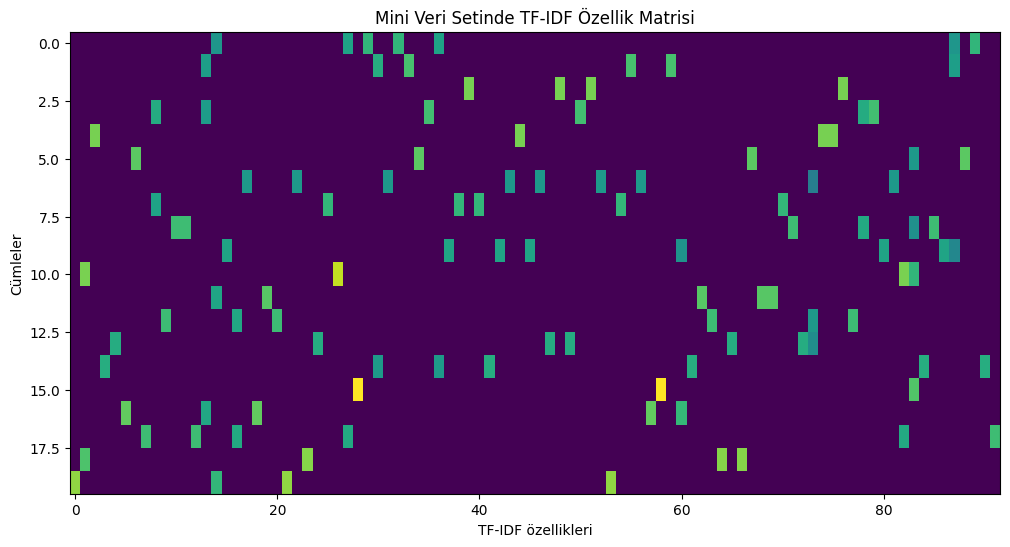

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.imshow(x.toarray(), aspect="auto")

plt.xlabel("TF-IDF özellikleri")
plt.ylabel("Cümleler")
plt.title("Mini Veri Setinde TF-IDF Özellik Matrisi")

plt.show()

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(data["insan_etiketi"])

print("Etiketler:", le.classes_)
print("Sayısal karşılıkları:", y)

Etiketler: ['negatif' 'nötr' 'pozitif']
Sayısal karşılıkları: [2 2 0 0 2 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0]


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_pred = cross_val_predict(
    model,
    x,
    y,
    cv=cv
)

print("Accuracy:", accuracy_score(y, y_pred))
print("\nClassification Report:\n")
print(classification_report(
    y,
    y_pred,
    target_names=le.classes_,
    zero_division=0
))

Accuracy: 0.65

Classification Report:

              precision    recall  f1-score   support

     negatif       0.65      1.00      0.79        13
        nötr       0.00      0.00      0.00         4
     pozitif       0.00      0.00      0.00         3

    accuracy                           0.65        20
   macro avg       0.22      0.33      0.26        20
weighted avg       0.42      0.65      0.51        20



C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


In [32]:
data["model_tahmini"] = le.inverse_transform(y_pred)

data[["ID", "METİN", "TUR", "insan_etiketi", "model_tahmini"]]

,ID,METİN,TUR,insan_etiketi,model_tahmini
0,1,Bugün her şey gerçekten çok güzel gitti.,açık,pozitif,negatif
1,2,Bu haberi görünce çok mutlu oldum.,açık,pozitif,negatif
2,3,Sonuçtan hiç memnun kalmadım.,açık,negatif,negatif
3,4,Bu uygulama tam bir hayal kırıklığı.,açık,negatif,negatif
4,5,Sonunda istediğim sonucu aldım.,ironi,pozitif,negatif
5,6,"Harika, yine üç saat bekledik.",ironi,negatif,negatif
6,7,"Ne kadar düşünceli, mesajıma iki gün sonra cev...",ironi,negatif,negatif
7,8,"Muhteşem bir hizmet, siparişim hâlâ gelmedi.",ironi,negatif,negatif
8,9,"Bravo, yine tam zamanında sistemi bozmuşlar.",ironi,negatif,negatif
9,10,"Çok iyi olmuş, zaten herkesin buna ihtiyacı va...",bağlam,negatif,negatif


In [33]:
data["dogru_mu"] = (
    data["insan_etiketi"] == data["model_tahmini"]
)

print(data["dogru_mu"].value_counts())

dogru_mu
True     13
False     7
Name: count, dtype: int64


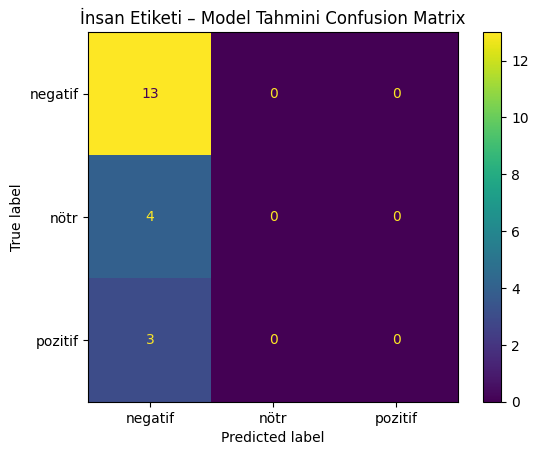

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot()
plt.title("İnsan Etiketi – Model Tahmini Confusion Matrix")
plt.show()

In [35]:
grup_hata = (
    data.groupby("tur")["dogru_mu"]
    .apply(lambda x: (~x).sum())
    .reset_index(name="hata_sayisi")
)

print(grup_hata)

             tur  hata_sayisi
0           açık            3
1         bağlam            4
2  internet_dili            0
3          ironi            0


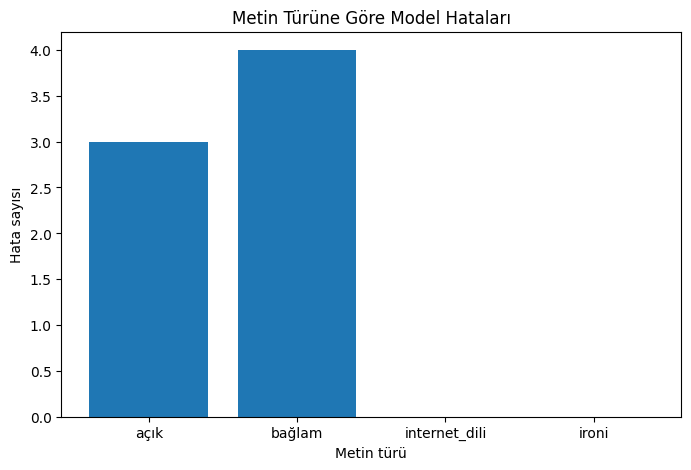

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(grup_hata["tur"], grup_hata["hata_sayisi"])

plt.xlabel("Metin türü")
plt.ylabel("Hata sayısı")
plt.title("Metin Türüne Göre Model Hataları")

plt.show()

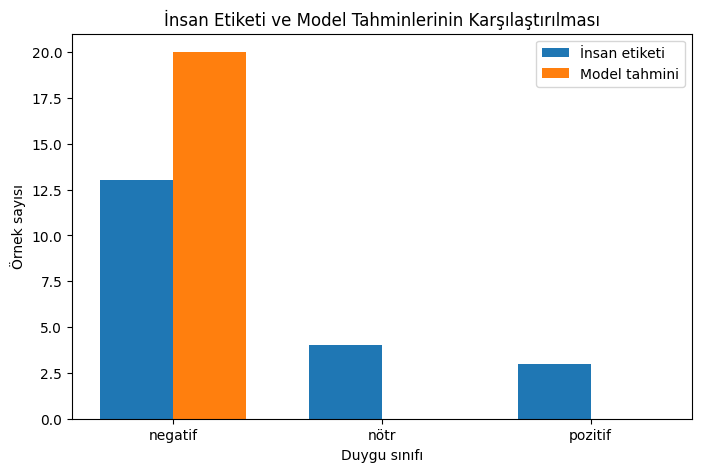

In [37]:
insan_dagilim = data["insan_etiketi"].value_counts().reindex(le.classes_, fill_value=0)
model_dagilim = data["model_tahmini"].value_counts().reindex(le.classes_, fill_value=0)

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(le.classes_))
genislik = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - genislik/2, insan_dagilim.values, genislik, label="İnsan etiketi")
plt.bar(x + genislik/2, model_dagilim.values, genislik, label="Model tahmini")

plt.xticks(x, le.classes_)
plt.ylabel("Örnek sayısı")
plt.xlabel("Duygu sınıfı")
plt.title("İnsan Etiketi ve Model Tahminlerinin Karşılaştırılması")
plt.legend()

plt.show()

In [39]:
hatalar = data[data["dogru_mu"] == False]

hatalar[[
    "ID",
    "METİN",
    "TUR",
    "insan_etiketi",
    "model_tahmini"
]]

,ID,METİN,TUR,insan_etiketi,model_tahmini
0,1,Bugün her şey gerçekten çok güzel gitti.,açık,pozitif,negatif
1,2,Bu haberi görünce çok mutlu oldum.,açık,pozitif,negatif
4,5,Sonunda istediğim sonucu aldım.,ironi,pozitif,negatif
10,11,Adam yine gerekeni yapmış.,bağlam,nötr,negatif
11,12,Bugün de ortalık sakin sayılır.,bağlam,nötr,negatif
12,13,Bunu söyledikten sonra ortam biraz değişti.,bağlam,nötr,negatif
14,15,Onu görünce yüzündeki ifade her şeyi anlattı.,internet_dili,nötr,negatif


TypeError: Invalid shape (3,) for image data

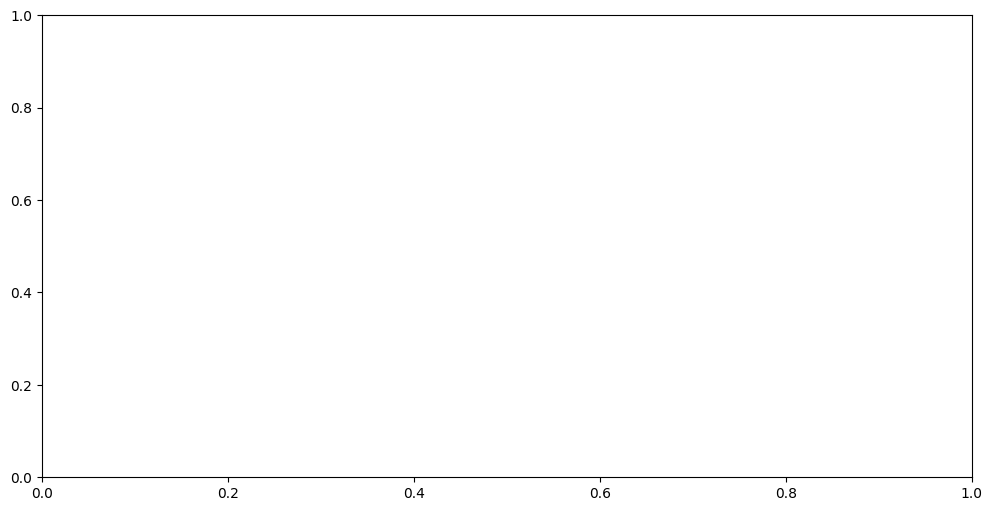

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# 1. TF-IDF Özellik Matrisi
# ==========================================

plt.figure(figsize=(12, 6))

plt.imshow(x, aspect="auto")

plt.xlabel("TF-IDF özellikleri")
plt.ylabel("Cümleler")
plt.title("Mini Veri Setinde TF-IDF Özellik Matrisi")

plt.show()


# ==========================================
# 2. Confusion Matrix
# ==========================================

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot()
plt.title("İnsan Etiketi – Model Tahmini Confusion Matrix")
plt.show()


# ==========================================
# 3. Metin Türüne Göre Model Hataları
# ==========================================

grup_hata = (
    data.groupby("TUR")["dogru_mu"]
    .apply(lambda x: (~x).sum())
    .reset_index(name="hata_sayisi")
)

plt.figure(figsize=(8, 5))
plt.bar(grup_hata["TUR"], grup_hata["hata_sayisi"])

plt.xlabel("Metin türü")
plt.ylabel("Hata sayısı")
plt.title("Metin Türüne Göre Model Hataları")
plt.show()


# ==========================================
# 4. İnsan Etiketi – Model Tahmini Dağılımı
# ==========================================

insan_dagilim = (
    data["insan_etiketi"]
    .value_counts()
    .reindex(le.classes_, fill_value=0)
)

model_dagilim = (
    data["model_tahmini"]
    .value_counts()
    .reindex(le.classes_, fill_value=0)
)

d = np.arange(len(le.classes_))
genislik = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    d - genislik/2,
    insan_dagilim.values,
    genislik,
    label="İnsan etiketi"
)

plt.bar(
    d + genislik/2,
    model_dagilim.values,
    genislik,
    label="Model tahmini"
)

plt.xticks(d, le.classes_)
plt.xlabel("Duygu sınıfı")
plt.ylabel("Örnek sayısı")
plt.title("İnsan Etiketi ve Model Tahminlerinin Karşılaştırılması")
plt.legend()

plt.show()

In [49]:
plt.savefig("tfidf_grafigi.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.savefig("tfidf_grafigi.png", dpi=300, bbox_inches="tight")
plt.show()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.savefig("metin_turu_hatalari.png", dpi=300, bbox_inches="tight")
plt.show()
plt.savefig("insan_model_karsilastirma.png", dpi=300, bbox_inches="tight")
plt.show()